<a href="https://colab.research.google.com/github/doradosanti/myProjects/blob/main/IS470_lab09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Given a data file by the San Francisco Bay Area Rapid Transit (BART), which identifies a set of demographics for residents in a local area. We will use this file to determine residents segmentations so that we can use it to develop marketing plans accordingly.<br>
<br>
VARIABLE DESCRIPTIONS:<br>
<br>
Age:

            1.   14 thru 17
            2.   18 thru 24
            3.   25 thru 34
            4.   35 thru 44
            5.   45 thru 54
            6.   55 thru 64
            7.   65 and Over

DistToWork: Distance to work in miles<br>
DualInc: Is dual income household or not<br>
Education:

            1. Grade 8 or less<br>
            2. Grades 9 to 11<br>
            3. Graduated high school<br>
            4. 1 to 3 years of college<br>
            5. College graduate<br>
            6. Grad Study<br>
Gender:	M or F<br>
Income:

            1. Less than $10,000<br>
            2. $10,000 to $14,999<br>
            3. $15,000 to $19,999<br>
            4. $20,000 to $24,999<br>
            5. $25,000 to $29,999<br>
            6. $30,000 to $39,999<br>
            7. $40,000 to $49,999<br>
            8. $50,000 to $74,999<br>
            9. $75,000 or more<br>
Language:	Language spoken at home<br>
NbrInHouseHold:	Number in household<br>
NbrInHouseholdUnder18:	Number in household under 18 years old<br>
OwnRent:	Own, rent, or live with parents<br>
YrsInArea:	Years lived in bay area<br>
Rider:	No, Non-rider; Yes, Rider<br>

###1. Upload and clean data

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import pandas as pd
from sklearn.cluster import KMeans
from collections import Counter
from sklearn import preprocessing
from matplotlib import pyplot as plt

In [ ]:
# Read data
BartRider = pd.read_csv("/content/drive/MyDrive/IS470_data/BartRider.csv")
BartRider

,Age,DistToWork,DualInc,Education,Gender,Income,Language,NbrInHouseHold,NbrInHouseholdUnder18,OwnRent,YrsInArea,Rider
0,3,10,N,4,F,7,English,1,0,Rent,3,Yes
1,3,11,N,4,M,6,English,3,1,Rent,2,No
2,2,10,N,5,M,6,English,2,0,Rent,3,No
3,5,6,Y,5,M,4,English,3,0,Rent,5,No
4,4,9,N,4,F,4,English,3,1,Rent,4,No
...,...,...,...,...,...,...,...,...,...,...,...,...
5488,2,9,N,2,F,1,English,5,1,Parent,6,Yes
5489,2,9,N,2,F,2,Other,4,1,Parent,4,Yes
5490,1,13,N,2,F,2,Spanish,4,2,Parent,1,Yes
5491,4,9,N,3,M,1,English,3,2,Parent,4,Yes


In [ ]:
# Show the head rows of a data frame
BartRider.head()

,Age,DistToWork,DualInc,Education,Gender,Income,Language,NbrInHouseHold,NbrInHouseholdUnder18,OwnRent,YrsInArea,Rider
0,3,10,N,4,F,7,English,1,0,Rent,3,Yes
1,3,11,N,4,M,6,English,3,1,Rent,2,No
2,2,10,N,5,M,6,English,2,0,Rent,3,No
3,5,6,Y,5,M,4,English,3,0,Rent,5,No
4,4,9,N,4,F,4,English,3,1,Rent,4,No


In [ ]:
# Examine variable type
BartRider.dtypes

,0
Age,int64
DistToWork,int64
DualInc,object
Education,int64
Gender,object
Income,int64
Language,object
NbrInHouseHold,int64
NbrInHouseholdUnder18,int64
OwnRent,object


In [ ]:
# Change categorical variables to "category"
BartRider['DualInc'] = BartRider['DualInc'].astype('category')
BartRider['Gender'] = BartRider['Gender'].astype('category')
BartRider['Language'] = BartRider['Language'].astype('category')
BartRider['OwnRent'] = BartRider['OwnRent'].astype('category')
BartRider['Rider'] = BartRider['Rider'].astype('category')

In [ ]:
# Examine variable type
BartRider.dtypes

,0
Age,int64
DistToWork,int64
DualInc,category
Education,int64
Gender,category
Income,int64
Language,category
NbrInHouseHold,int64
NbrInHouseholdUnder18,int64
OwnRent,category


###2. Prepare data set for clustering

In [ ]:
# Create dummy variables
BartRider = pd.get_dummies(BartRider, columns=['DualInc','Gender','Language','OwnRent','Rider'], drop_first=True, dtype=int)
BartRider

,Age,DistToWork,Education,Income,NbrInHouseHold,NbrInHouseholdUnder18,YrsInArea,DualInc_Y,Gender_M,Language_Other,Language_Spanish,OwnRent_Parent,OwnRent_Rent,Rider_Yes
0,3,10,4,7,1,0,3,0,0,0,0,0,1,1
1,3,11,4,6,3,1,2,0,1,0,0,0,1,0
2,2,10,5,6,2,0,3,0,1,0,0,0,1,0
3,5,6,5,4,3,0,5,1,1,0,0,0,1,0
4,4,9,4,4,3,1,4,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5488,2,9,2,1,5,1,6,0,0,0,0,1,0,1
5489,2,9,2,2,4,1,4,0,0,1,0,1,0,1
5490,1,13,2,2,4,2,1,0,0,0,1,1,0,1
5491,4,9,3,1,3,2,4,0,1,0,0,1,0,1


In [ ]:
# Apply minmax normalization
min_max_scaler = preprocessing.MinMaxScaler()
BartRider_normalized = pd.DataFrame(min_max_scaler.fit_transform(BartRider))
BartRider_normalized.columns = BartRider.columns
BartRider_normalized

,Age,DistToWork,Education,Income,NbrInHouseHold,NbrInHouseholdUnder18,YrsInArea,DualInc_Y,Gender_M,Language_Other,Language_Spanish,OwnRent_Parent,OwnRent_Rent,Rider_Yes
0,0.333333,0.35,0.6,0.750,0.0,0.000000,0.2,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.333333,0.40,0.6,0.625,0.4,0.333333,0.1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.166667,0.35,0.8,0.625,0.2,0.000000,0.2,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.666667,0.15,0.8,0.375,0.4,0.000000,0.4,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.500000,0.30,0.6,0.375,0.4,0.333333,0.3,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5488,0.166667,0.30,0.2,0.000,0.8,0.333333,0.5,0.0,0.0,0.0,0.0,1.0,0.0,1.0
5489,0.166667,0.30,0.2,0.125,0.6,0.333333,0.3,0.0,0.0,1.0,0.0,1.0,0.0,1.0
5490,0.000000,0.50,0.2,0.125,0.6,0.666667,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
5491,0.500000,0.30,0.4,0.000,0.4,0.666667,0.3,0.0,1.0,0.0,0.0,1.0,0.0,1.0


## 3. Clustering model

In [ ]:
# Build a clustering model with n_clusters = 2. Set random_state=0.
model1 = KMeans(n_clusters=2, random_state=0)
model1.fit(BartRider_normalized)

KMeans(n_clusters=2, random_state=0)

In [ ]:
# Generate the cluster labels
model1.labels_

array([1, 0, 0, ..., 1, 1, 1], dtype=int32)

In [ ]:
# Show cluster size
Counter(model1.labels_)

Counter({np.int32(1): 2185, np.int32(0): 3308})

In [ ]:
# Show cluster centroids
pd.DataFrame({'cluster 1':BartRider[model1.labels_==0].mean(axis=0), 'cluster 2':BartRider[model1.labels_==1].mean(axis=0)})

,cluster 1,cluster 2
Age,4.209190,2.375286
DistToWork,11.487001,11.429748
Education,4.302297,3.222426
Income,6.178960,3.605492
NbrInHouseHold,2.586457,3.435698
NbrInHouseholdUnder18,0.529625,0.981236
YrsInArea,4.333132,4.234783
DualInc_Y,0.412031,0.004577
Gender_M,0.462817,0.450343
Language_Other,0.025393,0.048055


The percentage of rider for cluster one is 8% and for cluster two 93%

My interpretation based on attributes: Cluster two could be students living with their parents have lower income and most of them are bart riders. Cluster one could be working professionals, who have a family, have higher income and educatuion level, own their houses and dont use the bart.

In [ ]:
# Build a clustering model with n_clusters = 3 (1 point)
model2 = KMeans(n_clusters=3, random_state=0)
model2.fit(BartRider_normalized)


KMeans(n_clusters=3, random_state=0)

In [ ]:
# Generate the cluster labels (1 point)
model2.labels_

array([2, 2, 2, ..., 1, 1, 1], dtype=int32)

In [ ]:
# Show cluster size (1 point)
Counter(model2.labels_)

Counter({np.int32(2): 1810, np.int32(0): 2293, np.int32(1): 1390})

In [ ]:
# Show cluster centroids (1 point)
pd.DataFrame({'cluster 1':BartRider[model2.labels_==0].mean(axis=0), 'cluster 2':BartRider[model2.labels_==1].mean(axis=0), 'cluster 3':BartRider[model2.labels_==2].mean(axis=0),})

,cluster 1,cluster 2,cluster 3
Age,4.702573,1.813669,3.209945
DistToWork,11.447449,11.428777,11.512707
Education,4.451810,2.761151,3.992818
Income,7.102486,2.932374,4.395580
NbrInHouseHold,2.799389,3.972662,2.277348
NbrInHouseholdUnder18,0.634104,1.265468,0.377348
YrsInArea,4.610118,4.383453,3.824862
DualInc_Y,0.464893,0.003597,0.166851
Gender_M,0.404710,0.423022,0.551934
Language_Other,0.020497,0.061871,0.030939





*   Cluster 1 could be "established working adults" as they are much older than the other two clusters, have higher education and income, and don't rent or live with parents.
*   Cluster 2 can be "young dependent students" as they are the youngest age group, lowest in education and income.
*   Cluster 3 "young/middle aged working professionals" as they rank moderate in education and income compared to the other clusters, are mostly renters and rely moderately on public transportation.


Based on the cluster size and centroids, I will use k = 3 because there is more to be revealed from the dataset and more distinctive compared to k=2. All three clusters are meaningful, clearer have differentiation, and better representation.

If I was part of a marketing team for BART figuring out how to target each cluster I would do the following:
*   Cluster 1 "established working adults": appeal convenience, comfort, and reliability such as campaigning BART as a stress free commute and promoting Eco commute.
*   Cluster 2 "young dependent students": appeal affordability and family support such as transit discount passes and sponsoring local schools
*   Cluster 3 "young/middle aged working professionals": appeal to convenience and lifestyle flexibility such as such as positioning ourselves as the go to for nightlife




## 4. Elbow test to determine optimal number of clusters

Text(0.5, 1.0, 'Elbow Test')

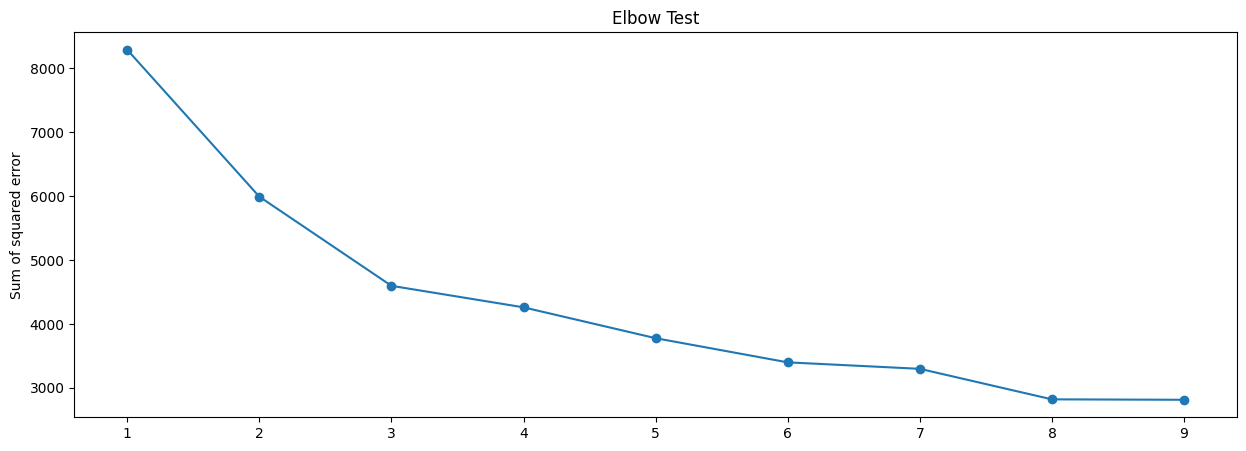

In [ ]:
Sum_of_squared_error = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(BartRider_normalized)
    Sum_of_squared_error.append(kmeans.inertia_)

fig = plt.figure(figsize=(15, 5))
plt.scatter(range(1, 10), Sum_of_squared_error)
plt.plot(range(1, 10), Sum_of_squared_error)
plt.ylabel('Sum of squared error')
plt.title('Elbow Test')


Three clusters may be the most optimal but there is no harm to trying other bigger k's to see what else the data can reveal

In [ ]:
# Build a clustering model with n_clusters = 3 (1 point)
model3 = KMeans(n_clusters=4, random_state=0)
model3.fit(BartRider_normalized)

KMeans(n_clusters=4, random_state=0)

In [ ]:
# Generate the cluster labels (1 point)
model3.labels_

array([2, 2, 2, ..., 1, 1, 1], dtype=int32)

In [ ]:
# Show cluster size (1 point)
Counter(model3.labels_)

Counter({np.int32(2): 1795,
         np.int32(0): 1840,
         np.int32(3): 468,
         np.int32(1): 1390})

In [ ]:
# Show cluster centroids (1 point)
pd.DataFrame({'cluster 1':BartRider[model3.labels_==0].mean(axis=0), 'cluster 2':BartRider[model3.labels_==1].mean(axis=0), 'cluster 3':BartRider[model3.labels_==2].mean(axis=0),'cluster 4':BartRider[model3.labels_==3].mean(axis=0)})

,cluster 1,cluster 2,cluster 3,cluster 4
Age,4.700543,1.813669,3.200557,4.698718
DistToWork,11.402717,11.428777,11.503621,11.660256
Education,4.446196,2.761151,3.991643,4.463675
Income,7.083152,2.932374,4.374373,7.173077
NbrInHouseHold,2.795652,3.972662,2.274652,2.807692
NbrInHouseholdUnder18,0.643478,1.265468,0.376045,0.594017
YrsInArea,4.625543,4.383453,3.822841,4.532051
DualInc_Y,0.586957,0.003597,0.160446,0.000000
Gender_M,0.250543,0.423022,0.555989,1.000000
Language_Other,0.017935,0.061871,0.030641,0.032051


In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/IS470_lab09.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS470_lab09.ipynb to html
[NbConvertApp] Writing 305839 bytes to /content/drive/MyDrive/Colab Notebooks/IS470_lab09.html
